In [1]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # matplotlib의 핵심 모듈
import seaborn as sns              # 통계 시각화 라이브러리
import warnings
warnings.filterwarnings('ignore')  # 경고 메시지 숨김

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'        # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False          # 마이너스 부호 깨짐 방지
plt.rcParams['figure.figsize'] = (10, 6)            # 기본 그래프 크기
plt.rcParams['figure.dpi'] = 100                    # 해상도

# Jupyter 노트북에서 그래프 인라인 표시
%matplotlib inline

print("라이브러리 로드 완료!")
print(f"matplotlib 버전: {plt.matplotlib.__version__}")
print(f"seaborn 버전: {sns.__version__}")

라이브러리 로드 완료!
matplotlib 버전: 3.8.3
seaborn 버전: 0.13.2


In [2]:
# 데이터 로드 (이번 수업에서 사용할 7개 데이터셋)
# 1) 컴퓨터 가격 데이터
df_comp = pd.read_csv('pandas/data/computer_prices_all.csv')

# 2) 상하수도 요금 데이터
df_water = pd.read_csv('pandas/data/경상북도 안동시_상하수도요금정보_20251124.csv', encoding='cp949')

# 3) Spotify 2023 인기곡
df_spotify = pd.read_csv('pandas/data/spotify-2023.csv', encoding='latin-1')

# 4) 타이타닉 생존 데이터
df_titanic = pd.read_csv('pandas/data/titanic_train.csv')

# 5) 국세청 사업자현황
df_biz = pd.read_csv('pandas/data/국세청_사업자현황_성별_20240930.csv', encoding='cp949')

# 6) 서울 지하철 혼잡도
df_subway = pd.read_csv('pandas/data/서울교통공사_ 혼잡도_20171231.csv', encoding='cp949')

# 7) 캘리포니아 주택 가격
df_housing = pd.read_csv('pandas/data/california_housing_test.csv')

print("=== 데이터 로드 완료 ===")
for name, df in [('컴퓨터 가격', df_comp), ('상하수도 요금', df_water), ('Spotify', df_spotify),
                  ('타이타닉', df_titanic), ('사업자현황', df_biz), ('지하철 혼잡도', df_subway),
                  ('주택 가격', df_housing)]:
    print(f"  {name}: {df.shape[0]:>8,}행 × {df.shape[1]}열")

=== 데이터 로드 완료 ===
  컴퓨터 가격:  100,000행 × 33열
  상하수도 요금:  471,984행 × 6열
  Spotify:      953행 × 24열
  타이타닉:      891행 × 8열
  사업자현황:    8,527행 × 13열
  지하철 혼잡도:    1,668행 × 44열
  주택 가격:    3,000행 × 9열


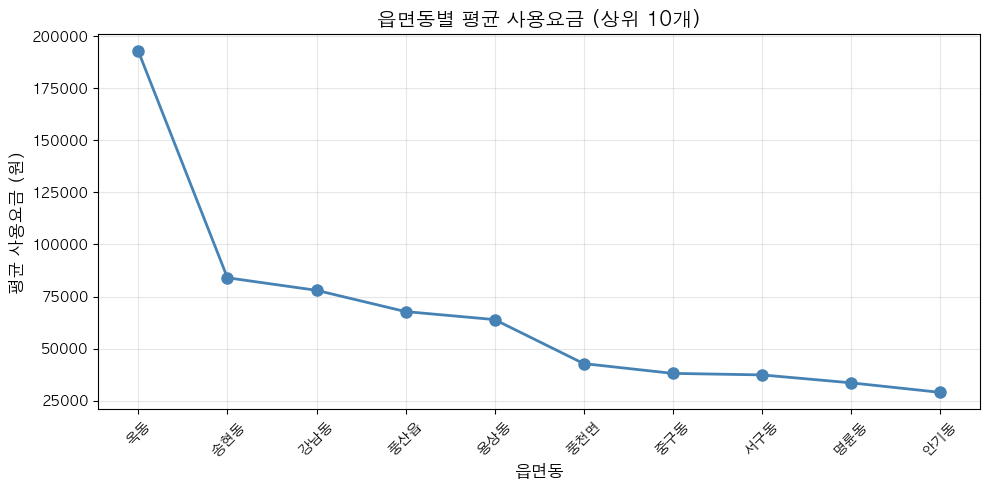

In [4]:
# 가장 기본적인 선 그래프 (Line Plot)
# 상하수도 데이터: 읍면동별 평균 사용요금

# 데이터 준비 - 읍면동별 평균 요금 (상위 10개 지역)
dong_avg = df_water.groupby('읍면동명')['사용요금'].mean().sort_values(ascending=False).head(10)

# plt 방식 - 빠르고 간편한 시각화
plt.figure(figsize=(10, 5))                          # 그래프 크기 설정
plt.plot(dong_avg.index, dong_avg.values,            # x축: 읍면동명, y축: 평균요금
         marker='o',                                  # 데이터 포인트 마커
         color='steelblue',                           # 선 색상
         linewidth=2,                                 # 선 두께
         markersize=8)                                # 마커 크기

plt.title('읍면동별 평균 사용요금 (상위 10개)', fontsize=14, fontweight='bold')  # 제목
plt.xlabel('읍면동', fontsize=12)                     # x축 라벨
plt.ylabel('평균 사용요금 (원)', fontsize=12)          # y축 라벨
plt.xticks(rotation=45)                               # x축 라벨 회전
plt.grid(True, alpha=0.3)                             # 격자선 (투명도 0.3)
plt.tight_layout()                                    # 레이아웃 자동 조정
plt.show()


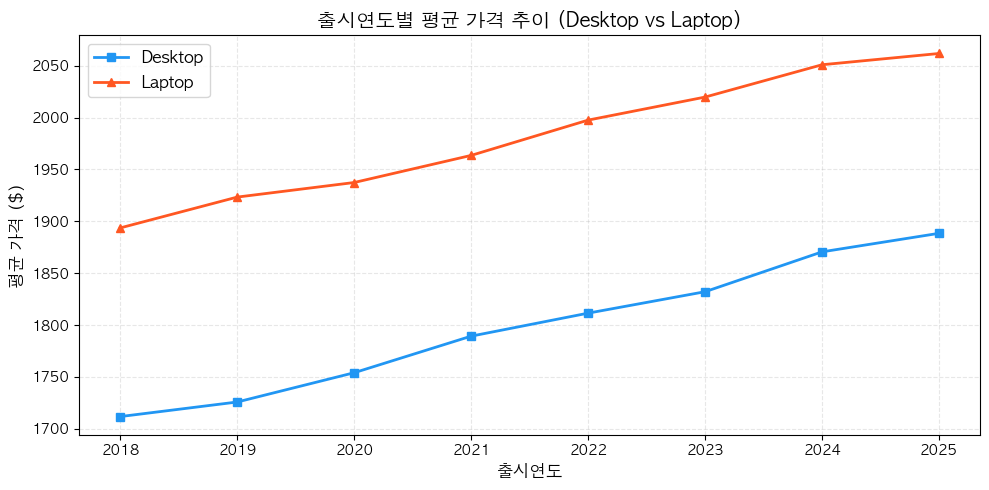

In [5]:
# 여러 선을 하나의 그래프에 그리기 + 범례(legend)
# 컴퓨터 데이터: 출시연도별 Desktop vs Laptop 평균 가격 추이

# 데이터 준비
yearly_price = df_comp.groupby(['release_year', 'device_type'])['price'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))              # 객체지향 방식

# 각 기기유형별 선 그래프
ax.plot(yearly_price.index, yearly_price['Desktop'],
        marker='s', label='Desktop', color='#2196F3', linewidth=2)
ax.plot(yearly_price.index, yearly_price['Laptop'],
        marker='^', label='Laptop', color='#FF5722', linewidth=2)

ax.set_title('출시연도별 평균 가격 추이 (Desktop vs Laptop)', fontsize=14, fontweight='bold')
ax.set_xlabel('출시연도', fontsize=12)
ax.set_ylabel('평균 가격 ($)', fontsize=12)
ax.legend(fontsize=12, loc='upper left')              # 범례 표시
ax.grid(True, alpha=0.3, linestyle='--')              # 점선 격자
plt.tight_layout()
plt.show()

In [16]:
df_subway.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1668 entries, 0 to 1667
Data columns (total 44 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   요일          1668 non-null   object 
 1   호선          1668 non-null   object 
 2   역번호         1668 non-null   int64  
 3   역명          1668 non-null   object 
 4   방향          1668 non-null   object 
 5   5:30~ (%)   1668 non-null   float64
 6   6:00~ (%)   1668 non-null   float64
 7   6:30~ (%)   1668 non-null   float64
 8   7:00~ (%)   1668 non-null   float64
 9   7:30~ (%)   1668 non-null   float64
 10  8:00~ (%)   1668 non-null   float64
 11  8:30~ (%)   1668 non-null   float64
 12  9:00~ (%)   1668 non-null   float64
 13  9:30~ (%)   1668 non-null   float64
 14  10:00~ (%)  1668 non-null   float64
 15  10:30~ (%)  1668 non-null   float64
 16  11:00~ (%)  1668 non-null   float64
 17  11:30~ (%)  1668 non-null   float64
 18  12:00~ (%)  1668 non-null   float64
 19  12:30~ (%)  1668 non-null  

In [19]:
# 서울교통공사 호선별 시간대별 평균 혼잡도 라인 그래프 (평일)

# 시간대 컬럼 추출
# time_cols = [c for c in df_subway.columns if '~' in c]
time_cols = df_subway.columns[5:]
main_lines = df_subway['호선'].value_counts().keys().to_list()
main_lines.sort()
print(main_lines)


df_subway_weekday = df_subway[df_subway['요일']=='평일']
df_subway_weekday.info()


['1', '2', '3', '4', '5', '6', '7', '8', '성수지선', '신정지선']
<class 'pandas.core.frame.DataFrame'>
Index: 556 entries, 0 to 555
Data columns (total 44 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   요일          556 non-null    object 
 1   호선          556 non-null    object 
 2   역번호         556 non-null    int64  
 3   역명          556 non-null    object 
 4   방향          556 non-null    object 
 5   5:30~ (%)   556 non-null    float64
 6   6:00~ (%)   556 non-null    float64
 7   6:30~ (%)   556 non-null    float64
 8   7:00~ (%)   556 non-null    float64
 9   7:30~ (%)   556 non-null    float64
 10  8:00~ (%)   556 non-null    float64
 11  8:30~ (%)   556 non-null    float64
 12  9:00~ (%)   556 non-null    float64
 13  9:30~ (%)   556 non-null    float64
 14  10:00~ (%)  556 non-null    float64
 15  10:30~ (%)  556 non-null    float64
 16  11:00~ (%)  556 non-null    float64
 17  11:30~ (%)  556 non-null    float64
 18  12:00~ (%)  556 no

['5:30', '6:00', '6:30', '7:00', '7:30', '8:00', '8:30', '9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30', '23:00', '23:30', '24:00', '24:30']


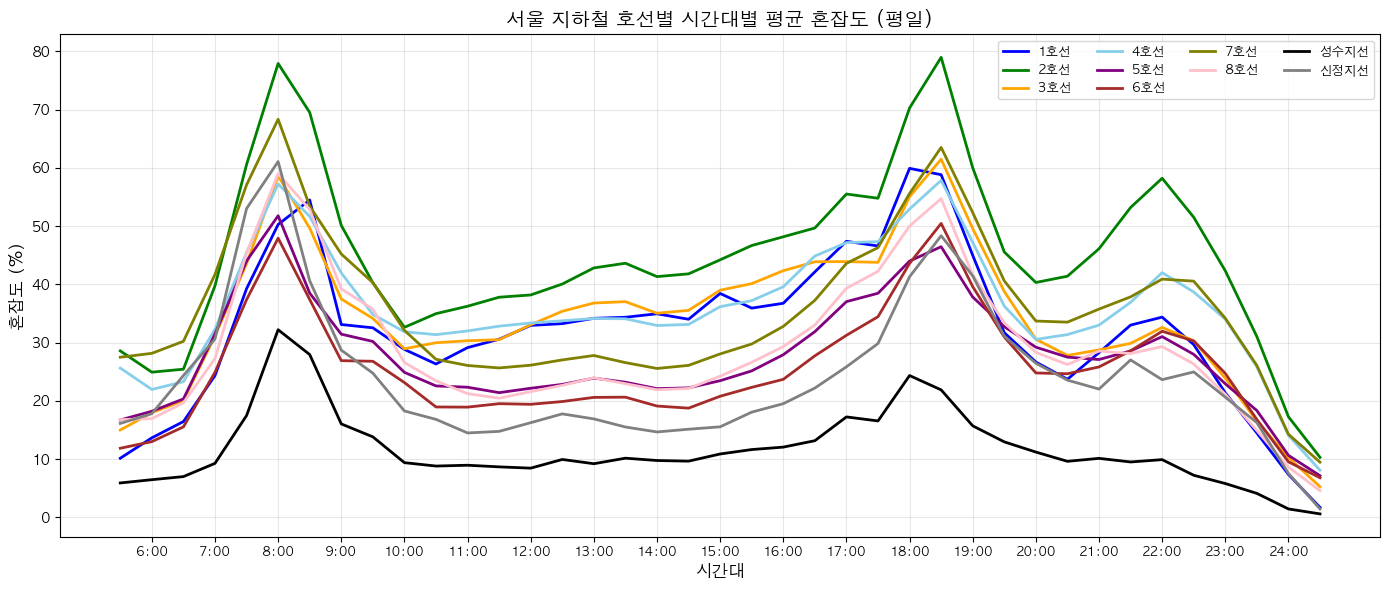

In [27]:
line_avg = df_subway_weekday.groupby('호선')[time_cols].mean()
color_list = ['blue', 'green', 'orange', 'skyblue', 'purple', 'brown', 'olive', 'pink', 'black', 'gray']
colors = { l:c  for l,c in zip(main_lines, color_list) }


fig, ax = plt.subplots(figsize=(14, 6))
for line in main_lines:
    if line in line_avg.index:
        ax.plot(line_avg.loc[line].values, color=colors[line], linewidth=2, label= f'{line}호선' if line.isdecimal() else line)

# x축 라벨: 정각(:00)만 표시 (39개 중 20개만 표시하여 가독성 확보)
labels = [c.replace('~ (%)', '').strip() for c in time_cols]
major_idx = [i for i, l in enumerate(labels) if l.endswith(':00')]
ax.set_xticks(major_idx)
ax.set_xticklabels([labels[i] for i in major_idx], fontsize=9)

ax.set_title('서울 지하철 호선별 시간대별 평균 혼잡도 (평일)', fontsize=14, fontweight='bold')
ax.set_xlabel('시간대', fontsize=12)
ax.set_ylabel('혼잡도 (%)', fontsize=12)
ax.legend(fontsize=9, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



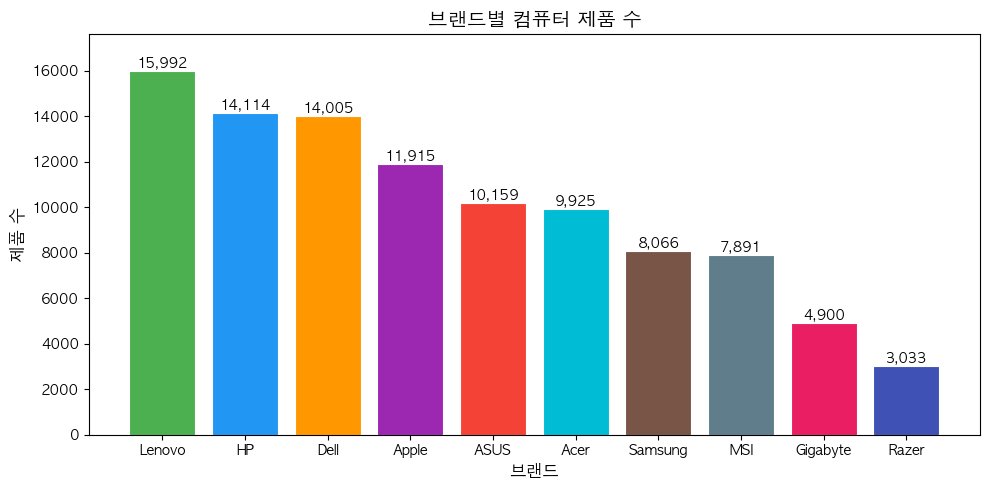

In [31]:
brand_counts = df_comp['brand'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))

color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336',
                     '#00BCD4', '#795548', '#607D8B', '#E91E63', '#3F51B5']

bars = ax.bar(brand_counts.index, brand_counts.values, color=color, edgecolor='white', linewidth=0.8)
# 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}',                          # 천 단위 콤마
            ha='center', va='bottom', fontsize=10)
    
ax.set_title('브랜드별 컴퓨터 제품 수', fontsize=14, fontweight='bold')
ax.set_xlabel('브랜드', fontsize=12)
ax.set_ylabel('제품 수', fontsize=12)
ax.set_ylim(0, brand_counts.max() * 1.1)             # y축 여유 공간
plt.tight_layout()
plt.show()

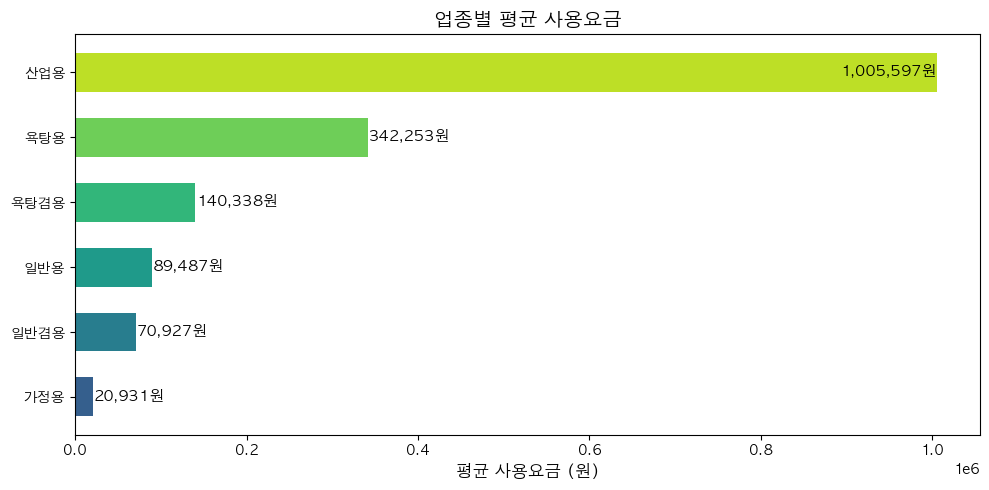

In [41]:
usage_by_type = df_water.groupby('업종')['사용요금'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))

# 수평 막대 그래프
bars = ax.barh(usage_by_type.index, usage_by_type.values,
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(usage_by_type))),  # 컬러맵 사용
               height=0.6)

# 막대 끝에 값 표시
for bar in bars:
    width = bar.get_width()
    ax.text(width + 500, bar.get_y() + bar.get_height()/2.,
            f'{width:,.0f}원', ha='right' if bar.get_width() >=1000000 else 'left', va='center', fontsize=11)

ax.set_title('업종별 평균 사용요금', fontsize=14, fontweight='bold')
ax.set_xlabel('평균 사용요금 (원)', fontsize=12)
plt.tight_layout()
plt.show()

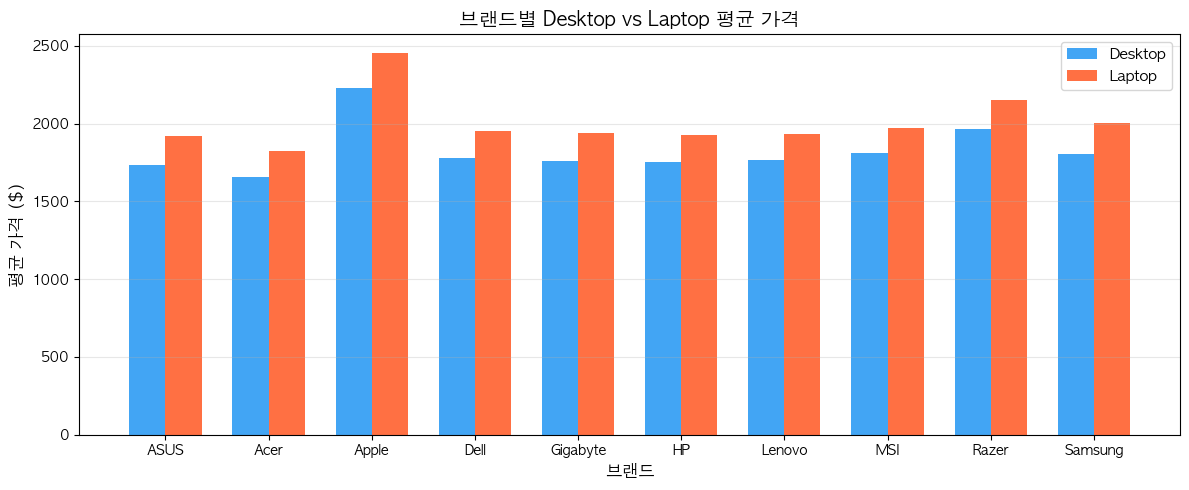

In [48]:
brand_type_price = df_comp.groupby(['brand', 'device_type'])['price'].mean().unstack(fill_value=0)


fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(brand_type_price.index))   # x 위치
width = 0.35                                    # 막대 너비

# 두 그룹의 막대를 나란히 배치
bars1 = ax.bar(x - width/2, brand_type_price['Desktop'], width,
               label='Desktop', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, brand_type_price['Laptop'], width,
               label='Laptop', color='#FF5722', alpha=0.85)

ax.set_title('브랜드별 Desktop vs Laptop 평균 가격', fontsize=14, fontweight='bold')
ax.set_xlabel('브랜드', fontsize=12)
ax.set_ylabel('평균 가격 ($)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(brand_type_price.index)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 누적 막대 그래프 (Stacked Bar Chart)
# 상하수도 데이터: 읍면동별 업종별 건수 구성비

# 데이터 준비 - 상위 8개 읍면동의 업종별 건수
top_dongs = df_water['읍면동명'].value_counts().head(8).index
dong_type = df_water[df_water['읍면동명'].isin(top_dongs)].groupby(
    ['읍면동명', '업종']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# 누적 막대 그래프 (DataFrame의 plot 메서드 활용)
dong_type.plot(kind='bar', stacked=True, ax=ax,
               colormap='Set2', edgecolor='white', linewidth=0.5)

ax.set_title('읍면동별 업종 구성 (상위 8개 지역)', fontsize=14, fontweight='bold')
ax.set_xlabel('읍면동', fontsize=12)
ax.set_ylabel('건수', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(title='업종', bbox_to_anchor=(1.02, 1), loc='upper left')  # 범례를 그래프 밖에 배치
plt.tight_layout()
plt.show()

In [ ]:
# 기본 히스토그램
# 컴퓨터 데이터: 가격 분포

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌측: 기본 히스토그램
axes[0].hist(df_comp['price'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('컴퓨터 가격 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('가격 ($)')
axes[0].set_ylabel('빈도')
axes[0].axvline(df_comp['price'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"평균: ${df_comp['price'].mean():,.0f}")
axes[0].legend(fontsize=11)

# 우측: bins 수 조절 + 밀도(density)
axes[1].hist(df_comp['price'], bins=50, density=True,
             color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('컴퓨터 가격 확률 밀도', fontsize=13, fontweight='bold')
axes[1].set_xlabel('가격 ($)')
axes[1].set_ylabel('확률 밀도')

plt.tight_layout()
plt.show()